In [1]:
import torch 
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
words = open('names (1).txt','r').read().splitlines() 
words

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn',
 'abigail',
 'emily',
 'elizabeth',
 'mila',
 'ella',
 'avery',
 'sofia',
 'camila',
 'aria',
 'scarlett',
 'victoria',
 'madison',
 'luna',
 'grace',
 'chloe',
 'penelope',
 'layla',
 'riley',
 'zoey',
 'nora',
 'lily',
 'eleanor',
 'hannah',
 'lillian',
 'addison',
 'aubrey',
 'ellie',
 'stella',
 'natalie',
 'zoe',
 'leah',
 'hazel',
 'violet',
 'aurora',
 'savannah',
 'audrey',
 'brooklyn',
 'bella',
 'claire',
 'skylar',
 'lucy',
 'paisley',
 'everly',
 'anna',
 'caroline',
 'nova',
 'genesis',
 'emilia',
 'kennedy',
 'samantha',
 'maya',
 'willow',
 'kinsley',
 'naomi',
 'aaliyah',
 'elena',
 'sarah',
 'ariana',
 'allison',
 'gabriella',
 'alice',
 'madelyn',
 'cora',
 'ruby',
 'eva',
 'serenity',
 'autumn',
 'adeline',
 'hailey',
 'gianna',
 'valentina',
 'isla',
 'eliana',
 'quinn',
 'nevaeh',
 'ivy',
 'sadie',
 'piper',
 'lydia',
 'alexa',
 'josephine',
 'emery',
 'julia'

In [3]:
chars= sorted(list(set(''.join(words))))
mapping  = {c : i+1  for i,c in enumerate(chars)}
mapping['.'] = 0
reverse_mapping = {i:c for c,i in mapping.items()}
vocab_size = len(reverse_mapping)
print(reverse_mapping)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [4]:
import random
block_size = 3
def Build_dataset(words):
    
    X , y = [] , []
    for w in words:
        #print(w)
        context = [0]*block_size
        for ch in w + '.':
            ix = mapping[ch]
            X.append(context)
            y.append(ix)
            #print(''.join(reverse_mapping[i] for i in context) ,'---->' , reverse_mapping[ix])
            context = context[1:] + [ix]
        
    X=torch.tensor(X)
    y=torch.tensor(y)
    return X ,y

random.seed(42)
random.shuffle(words)
n1 =int(0.8*len(words))
n2 =int(0.9*len(words))

Xtr , ytr = Build_dataset(words[:n1])
Xdv , ydv = Build_dataset(words[n1:n2])
Xts , yts = Build_dataset(words[n2:])

In [5]:
n_embd = 10
n_hidden = 200


g=torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
W1= torch.randn((n_embd * block_size, n_hidden), generator=g) *(5/3)/((n_embd * block_size)**0.5)
b1 = torch.rand(n_hidden , generator=g) *0.01
W2 = torch.randn((n_hidden , vocab_size) , generator=g) * 0.01
b2 = torch.randn(vocab_size , generator=g) * 0 

bngain = torch.ones((1,n_hidden))
bnbias = torch.zeros((1,n_hidden))
bnmean_running = torch.zeros((1,n_hidden))
bnstd_running = torch.ones((1,n_hidden))

parameters = [C,W1,b1,W2,b2 , bngain , bnbias]

print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

12297


In [6]:
max_steps = 200000
lossi = []
batch_size = 32

for i in range(max_steps):
    #minibatch
    ix = torch.randint(0 , Xtr.shape[0] , (batch_size,  ), generator=g)
    xb = Xtr[ix]
    yb = ytr[ix]

    #forward pass 
    emb = C[xb]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1

    bnmeani = hpreact.mean(0 , keepdim=True)
    bnstdi = hpreact.std(0 , keepdim=True)

    hpreact = bngain * (hpreact - bnmeani) / (bnstdi + 1e-5) + bnbias
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
        
    h = torch.tanh(hpreact)
    logits = h @ W2  + b2
    loss =F.cross_entropy(logits , yb)
    
    #backward pass 
    for p in parameters:
        p.grad= None
    loss.backward()

    #update 
    lr = 0.1 if i < 10000 else 0.01 
    for p in parameters:
        p.data += - lr* p.grad
    # lri.append(lre[i])
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi.append(loss.log10().item())



      0/200000: 3.2906
  10000/200000: 1.9757
  20000/200000: 1.8456
  30000/200000: 2.0796
  40000/200000: 2.2380
  50000/200000: 2.4394
  60000/200000: 2.0148
  70000/200000: 1.7101
  80000/200000: 2.2012
  90000/200000: 2.1473
 100000/200000: 2.1367
 110000/200000: 2.4159
 120000/200000: 1.7462
 130000/200000: 2.2031
 140000/200000: 2.1800
 150000/200000: 2.2209
 160000/200000: 2.2265
 170000/200000: 1.6162
 180000/200000: 1.9122
 190000/200000: 2.0573


In [7]:
with torch.no_grad():
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    
    bnmean = hpreact.mean(0 , keepdim=True)
    bnstd = hpreact.std(0 , keepdim=True)

In [8]:
@torch.no_grad()
def split_loss(split):
    x,y = {
        'train': (Xtr , ytr),
        'val': (Xdv , ydv),
        'test': (Xts , yts)
    }[split]
    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    hpreact = bngain * (hpreact - bnmean) / bnstd + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2  + b2
    loss =F.cross_entropy(logits , y)
    print(split, loss.item())
split_loss('train')
split_loss('val')


train 2.112222194671631
val 2.1389992237091064


tensor(-0.0028) tensor(1.0122)
tensor(-0.0019) tensor(1.0142)


(array([4.33912418e-05, 0.00000000e+00, 6.50868627e-05, 1.51869346e-04,
        2.60347451e-04, 5.64086143e-04, 8.67824836e-04, 9.11216078e-04,
        1.97430150e-03, 2.73364823e-03, 5.31542712e-03, 8.02737973e-03,
        1.31258506e-02, 2.13918822e-02, 3.17406934e-02, 4.84680171e-02,
        7.10965497e-02, 1.00559203e-01, 1.37268193e-01, 1.92244897e-01,
        2.53491635e-01, 3.15562806e-01, 3.76549196e-01, 4.22435434e-01,
        4.32350333e-01, 4.15492836e-01, 3.60993436e-01, 3.04389561e-01,
        2.37979266e-01, 1.77773918e-01, 1.29739813e-01, 9.16639983e-02,
        6.46312546e-02, 4.18074615e-02, 2.79873510e-02, 1.85714515e-02,
        1.17156353e-02, 7.65855418e-03, 4.90321032e-03, 2.86382196e-03,
        1.62717157e-03, 8.89520457e-04, 5.64086143e-04, 2.16956209e-04,
        1.73564967e-04, 8.67824836e-05, 1.08478104e-04, 0.00000000e+00,
        4.33912418e-05, 4.33912418e-05]),
 array([-5.61959839, -5.38913713, -5.15867588, -4.92821463, -4.69775337,
        -4.46729212, 

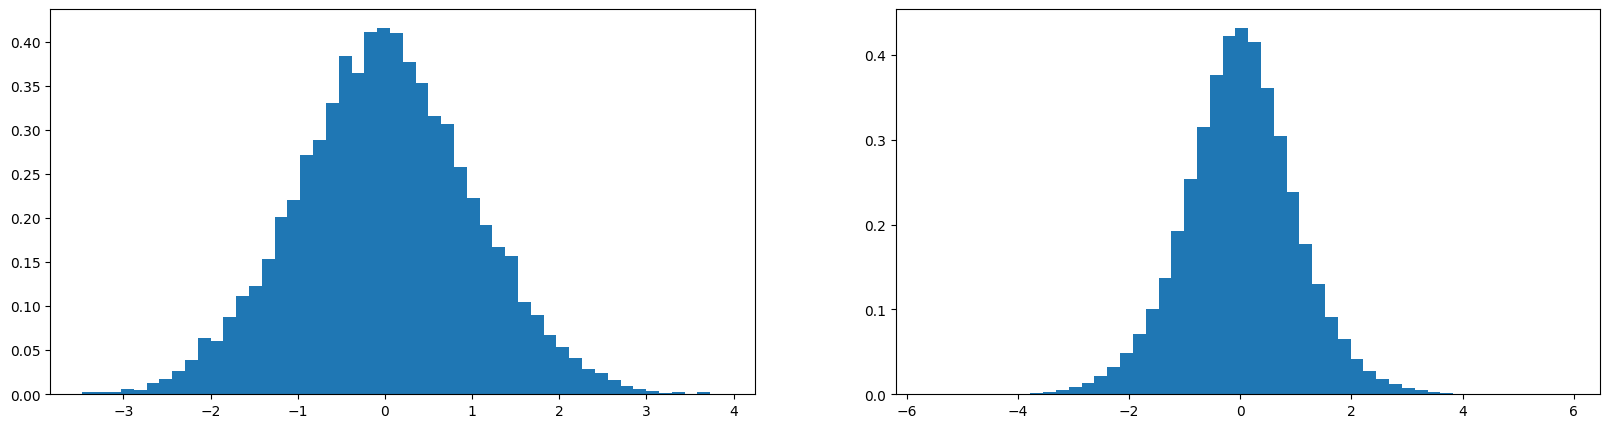

In [9]:
x = torch.randn(1000 , 10)
y = torch.randn(10 , 200) / 10 ** 0.5
y = x @ y
print(x.mean() , x.std())
print(y.mean() , y.std())
plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
plt.hist(x.view(-1).tolist(), 50 , density=True)
plt.subplot(1,2,2)
plt.hist(y.view(-1).tolist(), 50 , density=True)


In [10]:
hpreact.shape

torch.Size([182625, 200])

In [11]:
hpreact.mean(0 , keepdim=True).shape
hpreact.std(0 , keepdim=True).shape

torch.Size([1, 200])

In [22]:
class Linear:
    def __init__(self , fanin , fanout ,bias = True):
        self.weight = torch.randn((fanin , fanout) ,generator=g ) / fanout **0.5
        self.bias = torch.zeros(fanout) if bias else None 

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    def parameters(self):
        return [self.weight] + ([] if self.bias is not None else [self.bias])


class Batchnorm1d:
    def __init__(self , dim , epslon =1e-5 , momentum=0.1):
        self.epslon = epslon 
        self.momentum = momentum
        self.training = True
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        if self.training:
            xmean = x.mean(0 , Keepdim=True)
            xvar = x.var(0 , Keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x -xmean) / torch.sqrt(xvar + self.epslon)
        self.out = self.gamma * xhat + self.beta
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.monentum )*self.running_mean + self.momentum  * xmean
                self.running_var = (1 - self.monentum )*self.running_var + self.momentum  * xvar
        return self.out
    def parameters(self):
        return [self.beta , self.gamma]

class Tanh:
    def __call__(self,x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []




In [ ]:
n_embd = 10
n_hidden = 100
g=torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
layers = [
    Linear(n_embd*block_size , n_hidden) ,Batchnorm1d(n_hidden), Tanh() , 
    Linear(n_hidden,n_hidden) ,Batchnorm1d(n_hidden),Tanh(),
    Linear(n_hidden,n_hidden) ,Batchnorm1d(n_hidden),Tanh(),
    Linear(n_hidden,n_hidden) ,Batchnorm1d(n_hidden),Tanh(),
    Linear(n_hidden,n_hidden) ,Batchnorm1d(n_hidden),Tanh(),
    Linear(n_hidden,vocab_size) ,Batchnorm1d(vocab_size),
]

with torch.no_grad():
    layers[-1].gamma *=0.1
    for layer in layers[:-1]:
        if isinstance(layer ,Linear):
            layer.weight *= 5/3


parameters = [C] +[ p for layer in layers for p in layer.parameters()] 
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad =True


AttributeError: 'Batchnorm1d' object has no attribute 'weight'

In [26]:
max_steps = 200000
lossi = []
batch_size = 32

for i in range(max_steps):
    #minibatch
    ix = torch.randint(0 , Xtr.shape[0] , (batch_size,  ), generator=g)
    xb = Xtr[ix]
    yb = ytr[ix]

    #forward pass 
    emb = C[xb]
    x = emb.view(emb.shape[0], -1)
    for layer in layers :
        x = layer(x)
    loss = F.cross_entropy(x , yb)
    
    #backward pass
    for layer in layers :
        layer.out.retain_grad() 
    for p in parameters:
        p.grad= None
    loss.backward()

    #update 
    lr = 0.1 if i < 10000 else 0.01 
    for p in parameters:
        p.data += - lr* p.grad
    # lri.append(lre[i])
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    break


TypeError: mean() got an unexpected keyword argument 'Keepdim'